In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

### Let's build an easy calculator

In [17]:
class CalculatorState(TypedDict):
    num: float
    result: list

In [18]:
def add_10(state: CalculatorState) -> dict:
    
    new_value = state["num"] + 10
    result = state['result'] + [f"Added 10: {state['num']} + 10 = {new_value}"]
    print("Adding 10 to num")
    return {"num": new_value, "result": result}

def sub_10(state: CalculatorState) -> dict:
    print("Subtract the current value by 10")
    new_value = state["num"] - 10
    result = state['result'] + [f"Subtracted 10: {state['num']} - 10 = {new_value}"]
    return {"num": new_value, "result": result}

def mul_10(state: CalculatorState) -> dict:
    print("Multiplying current value by 10")
    new_value = state["num"] * 10
    result = state['result'] + [f"Multiplied 10: {state['num']} * 10 = {new_value}"]
    return {"num": new_value, "result": result}

def div_10(state: CalculatorState) -> dict:
    print("Dividing current value by 10")
    new_value = state["num"] / 10
    result = state['result'] + [f"Divided 10: {state['num']} / 10 = {new_value}"]
    return {"num": new_value, "result": result}

In [19]:
# Build the graph

graph = StateGraph(CalculatorState)

# Add nodes
graph.add_node("add_10", add_10)
graph.add_node("sub_10", sub_10)
graph.add_node("mul_10", mul_10)
graph.add_node("div_10", div_10)

# Add edges
graph.add_edge(START, "add_10")
graph.add_edge("add_10", "sub_10")
graph.add_edge("sub_10", "mul_10")
graph.add_edge("mul_10", "div_10")
graph.add_edge("div_10", END)

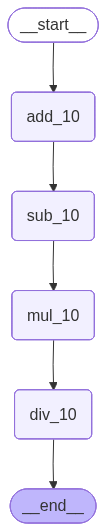

In [20]:
# Compile the graph
app = graph.compile()
app

In [23]:
# Execute the graph
result =app.invoke({"num":10.0, "result": []})
print(result)

Adding 10 to num
Subtract the current value by 10
Multiplying current value by 10
Dividing current value by 10
{'num': 10.0, 'result': ['Added 10: 10.0 + 10 = 20.0', 'Subtracted 10: 20.0 - 10 = 10.0', 'Multiplied 10: 10.0 * 10 = 100.0', 'Divided 10: 100.0 / 10 = 10.0']}
